# Stock Prices vs Stock Returns Visualization


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create Sample Stock Prices
# 10 days of hypothetical stock prices
prices = [100, 102, 101, 105, 107, 106, 110, 108, 111, 115]

# Create DataFrame
df = pd.DataFrame({
    'Day': range(1, 11),
    'Stock_Price': prices
})

df

,Day,Stock_Price
0,1,100
1,2,102
2,3,101
3,4,105
4,5,107
5,6,106
6,7,110
7,8,108
8,9,111
9,10,115


In [23]:
# 2. Calculate Daily Returns
# Return = (Today's Price - Yesterday's Price) / Yesterday's Price
df['Return'] = df['Stock_Price'].pct_change().round(3)

# Convert to percentage for easier interpretation
df['Return_Percent'] = df['Return'] * 100

df

,Day,Stock_Price,Return,Return_Percent
0,1,100,NaN,NaN
1,2,102,0.020,2.0
2,3,101,-0.010,-1.0
3,4,105,0.040,4.0
4,5,107,0.019,1.9
5,6,106,-0.009,-0.9
6,7,110,0.038,3.8
7,8,108,-0.018,-1.8
8,9,111,0.028,2.8
9,10,115,0.036,3.6


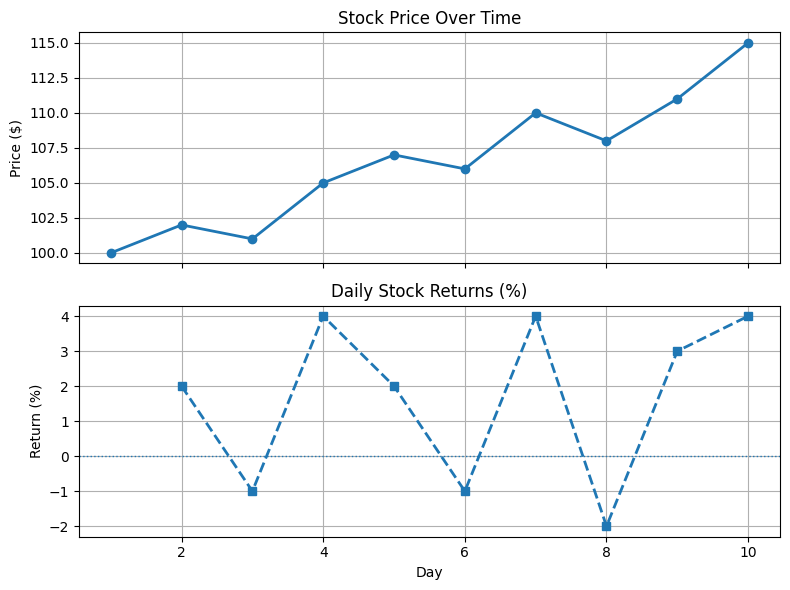

In [21]:
# Plot Price and Returns One Below Other

fig, (ax1, ax2) = plt.subplots(
    2, 1,                 # 2 rows, 1 column
    figsize=(8, 6),
    sharex=True           # Align x-axis (Day)
)

# -----------------------------
# Top Plot: Stock Price
# -----------------------------
ax1.plot(
    df['Day'],
    df['Stock_Price'],
    marker='o',
    linewidth=2
)
ax1.set_title('Stock Price Over Time')
ax1.set_ylabel('Price ($)')
ax1.grid(True)

# -----------------------------
# Bottom Plot: Daily Returns
# -----------------------------
ax2.plot(
    df['Day'],
    df['Return_Percent'],
    marker='s',
    linewidth=2,
    linestyle='--'
)
ax2.axhline(0, linestyle=':', linewidth=1)
ax2.set_title('Daily Stock Returns (%)')
ax2.set_xlabel('Day')
ax2.set_ylabel('Return (%)')
ax2.grid(True)

# Improve spacing
plt.tight_layout()
plt.show()

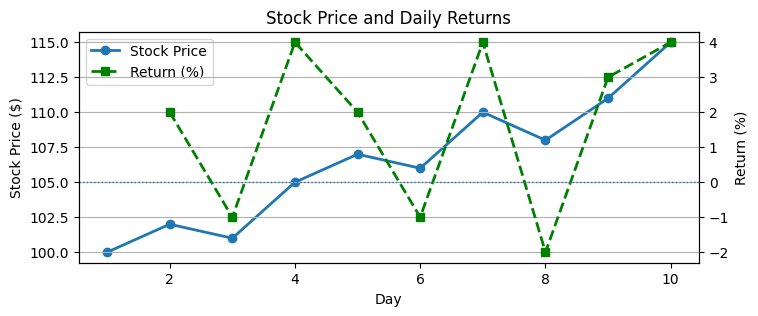

In [22]:

# ---------------------------------------
# Plot Stock Price and Returns Together
# ---------------------------------------

fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot Stock Price on left y-axis
ax1.plot(
    df['Day'],
    df['Stock_Price'],
    marker='o',
    linewidth=2,
    label='Stock Price'
)
ax1.set_xlabel('Day')
ax1.set_ylabel('Stock Price ($)')
ax1.tick_params(axis='y')

# Create second y-axis for Returns
ax2 = ax1.twinx()

# Plot Return % on right y-axis
ax2.plot(
    df['Day'],
    df['Return_Percent'],
    marker='s',
    linewidth=2,
    linestyle='--', color='green',
    label='Return (%)'
)
ax2.set_ylabel('Return (%)')
ax2.axhline(0, linestyle=':', linewidth=1)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left'
)

plt.title('Stock Price and Daily Returns')
plt.grid(True)
plt.show()

